# Clustering jerárquico sobre embeddings reducidos con autoencoder

Réplica del análisis de `hc_clustering.ipynb`, pero en lugar de usar los embeddings
originales, cada representación se **reduce de dimensión con un autoencoder** y el
**espacio latente** se usa como embedding para el clustering jerárquico (Ward).

| Técnica | Entrada al autoencoder |
|---|---|
| TF-IDF | TruncatedSVD a 50 componentes (LSA), L2-normalizado |
| MiniLM multilingüe | vectores densos de 384 dims, L2-normalizados |
| BGE-M3 (vLLM) | vectores densos de 1024 dims, L2-normalizados |
| BETO (chunking + pooling) | vectores densos de 768 dims, L2-normalizados |
| BETO whitened | 128 dims centradas y descorrelacionadas, L2-normalizadas |
| Nemotron VL (solo texto) | vectores densos de 2048 dims, L2-normalizados |

Las seis entradas son exactamente las de `hc_clustering.ipynb`, de modo que la única
diferencia entre ambos notebooks sea la reducción con autoencoder.

**Selección del autoencoder:** para cada técnica se entrena una grilla de configuraciones
(arquitectura del encoder × dimensión latente) y se elige la de **menor error de
reconstrucción (MSE) en un conjunto de validación** (15% de la muestra). Nota: a mayor
dimensión latente el error de reconstrucción tiende a bajar, por lo que este criterio
favorece los latentes más grandes de la grilla; se sigue igualmente por ser el criterio
definido para el experimento.

Nota sobre BETO whitened: el whitening ya descorrelaciona y trunca a 128 dims, así que el
autoencoder opera sobre un espacio previamente condicionado. Si su MSE resulta
anormalmente bajo, es por eso y no por mayor calidad de la representación.

Nota sobre Nemotron VL: con 2048 dims es la entrada más grande de la grilla, así que
comprimirla a 16–64 dims es la reducción más agresiva del experimento (128:1 en el caso
extremo). Un MSE alto frente a las demás técnicas puede reflejar esa razón de compresión y
no una representación peor; la comparación honesta es contra su propio desempeño en
`hc_clustering.ipynb`, no contra el MSE de técnicas de menor dimensión.

El resto del análisis es idéntico al de `hc_clustering.ipynb`: linkage de Ward,
correlación cofenética, silhouette / Calinski-Harabasz / Davies-Bouldin para k = 2…15,
dendrogramas, t-SNE y titulación de clústeres con DeepSeek vía vLLM.


In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from torch import nn

sys.path.insert(0, str(Path.cwd().parent))

PALETA = ["#2a78d6", "#008300", "#e87ba4", "#c9761a", "#7b5ea7", "#c0392b"]
sns.set_theme(style="whitegrid", palette=PALETA)
plt.rcParams.update({"figure.dpi": 100, "axes.grid": True, "grid.color": "#e1e0d9",
                     "axes.edgecolor": "#c3c2b7", "axes.labelcolor": "#52514e"})
RANDOM_STATE = 42
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"PyTorch {torch.__version__} — dispositivo: {DEVICE}")


def rejilla(n: int, ancho: float = 5.3, alto: float = 4.5, ncols: int = 3):
    """Rejilla de `n` paneles en `ncols` columnas; oculta los ejes sobrantes.

    Con seis técnicas una sola fila haría figuras de ~32 pulgadas de ancho,
    ilegibles al renderizar; el envoltorio en filas mantiene el tamaño por panel.
    """
    nfilas = -(-n // ncols)
    fig, axes = plt.subplots(nfilas, ncols, figsize=(ancho * ncols, alto * nfilas))
    axes = np.atleast_1d(axes).ravel()
    for ax in axes[n:]:
        ax.set_visible(False)
    return fig, axes[:n]


PyTorch 2.13.0+cpu — dispositivo: cpu


## Reproducción de la submuestra del EDA

Se replica exactamente la submuestra estratificada de ~1,500 artículos del EDA
(misma limpieza, mismos estratos año × periódico, mismo `random_state`) y se verifica
contra los `id_articulo` guardados en `data/embeddings/muestra_ids.npy` para garantizar
que los embeddings cacheados corresponden a estos textos.


In [2]:
import re
from math import ceil

data = pd.read_csv("../data/raw/stratified_sample_2019_2026.csv")
data.drop(columns=["anio", "id_pressreader", "id_periodico", "icor_index", "icor_v2_index"], inplace=True)
data["fecha"] = pd.to_datetime(data["fecha"])
data["anio"] = data["fecha"].dt.year


def norm_text(text: str) -> str:
    """Normaliza un texto: minúsculas y colapso de espacios en blanco."""
    text = text.lower()
    text = re.sub(r"\s+", " ", text)
    return text.strip()


data["texto_norm"] = data["texto"].map(norm_text)

N_MUESTRA = 1500
estratos = data.groupby(["nombre_periodico", "anio"])
cuota = ceil(N_MUESTRA / estratos.ngroups)
muestra = pd.concat(
    [g.sample(min(len(g), cuota), random_state=RANDOM_STATE) for _, g in estratos]
).sort_values(["anio", "nombre_periodico", "id_articulo"]).reset_index(drop=True)

textos_emb = (muestra["titulo"].fillna("").map(norm_text) + ". "
              + muestra["texto_norm"]).str.slice(0, 2000).tolist()

EMB_DIR = Path("../data/embeddings")
ids_muestra = muestra["id_articulo"].to_numpy()
assert np.array_equal(np.load(EMB_DIR / "muestra_ids.npy"), ids_muestra), \
    "La submuestra no coincide con la usada en el EDA: recalcular embeddings en eda.ipynb"
print(f"Submuestra reproducida: {len(muestra)} artículos — ids verificados contra el caché")


Submuestra reproducida: 1512 artículos — ids verificados contra el caché


## Carga de embeddings originales (entradas del autoencoder)

MiniLM y BGE-M3 se cargan del caché generado por `eda.ipynb`; TF-IDF se recalcula con
los mismos hiperparámetros y se reduce con `TruncatedSVD` a 50 componentes, igual que en
`hc_clustering.ipynb`. Todos se L2-normalizan: estos vectores son la **entrada** que el
autoencoder aprende a reconstruir.


In [3]:
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import normalize

vectorizador = TfidfVectorizer(max_features=50_000, min_df=3, max_df=0.6, sublinear_tf=True)
emb_tfidf_sparse = vectorizador.fit_transform(textos_emb)
emb_tfidf = TruncatedSVD(n_components=50, random_state=RANDOM_STATE).fit_transform(emb_tfidf_sparse)

emb_st = np.load(EMB_DIR / "minilm_multilingual.npy")
emb_bge = np.load(EMB_DIR / "bge_m3.npy")
emb_beto = np.load(EMB_DIR / "beto.npy")
emb_nemotron = np.load(EMB_DIR / "nemotron.npy")

N_COMP = 128


def whitening(emb: np.ndarray, n_comp: int = N_COMP) -> np.ndarray:
    """Centra y descorrelaciona `emb`, reteniendo las `n_comp` direcciones de mayor varianza.

    Misma transformación que en `hc_clustering.ipynb`, para que la comparación
    embedding original vs. latente sea sobre las mismas seis representaciones.
    """
    mu = emb.mean(axis=0)
    centrado = emb - mu
    # SVD de la covarianza: U son las direcciones principales, s sus varianzas.
    U, s, _ = np.linalg.svd(np.cov(centrado, rowvar=False))
    W = U[:, :n_comp] / np.sqrt(s[:n_comp])  # Sigma^(-1/2) truncada
    return centrado @ W


embeddings = {
    "TF-IDF (SVD-50)": normalize(emb_tfidf),
    "MiniLM multilingüe": normalize(emb_st),
    "BGE-M3": normalize(emb_bge),
    "BETO": normalize(emb_beto),
    "BETO (whitened)": normalize(whitening(emb_beto)),
    "Nemotron VL": normalize(emb_nemotron),
}
for nombre, emb in embeddings.items():
    print(f"{nombre}: {emb.shape}")


TF-IDF (SVD-50): (1512, 50)
MiniLM multilingüe: (1512, 384)
BGE-M3: (1512, 1024)
BETO: (1512, 768)
BETO (whitened): (1512, 128)


## Autoencoder: arquitectura y búsqueda de configuraciones

Autoencoder MLP **simétrico** (decoder espejo del encoder) con activaciones ReLU,
entrenado para minimizar el MSE de reconstrucción con Adam y *early stopping* sobre un
conjunto de validación (15% de la muestra, partición fija con `RANDOM_STATE`).

Grilla de pruebas por técnica:

- **Dimensión latente:** 16, 32, 64 (se omiten latentes ≥ dimensión de entrada).
- **Capas ocultas del encoder:** ninguna (`entrada → latente`), una (`entrada → 128 → latente`)
  y dos (`entrada → 256 → 128 → latente`).

Para cada técnica se conserva el autoencoder con **menor MSE de validación** y su espacio
latente reemplaza al embedding original en el resto del análisis.


In [4]:
class Autoencoder(nn.Module):
    """Autoencoder MLP simétrico: decoder espejo del encoder, activaciones ReLU."""

    def __init__(self, dim_entrada: int, dims_ocultas: list[int], dim_latente: int):
        super().__init__()
        dims_enc = [dim_entrada, *dims_ocultas]
        capas_enc = []
        for d_in, d_out in zip(dims_enc, dims_enc[1:]):
            capas_enc += [nn.Linear(d_in, d_out), nn.ReLU()]
        capas_enc.append(nn.Linear(dims_enc[-1], dim_latente))
        self.encoder = nn.Sequential(*capas_enc)

        dims_dec = [dim_latente, *reversed(dims_ocultas)]
        capas_dec = []
        for d_in, d_out in zip(dims_dec, dims_dec[1:]):
            capas_dec += [nn.Linear(d_in, d_out), nn.ReLU()]
        capas_dec.append(nn.Linear(dims_dec[-1], dim_entrada))
        self.decoder = nn.Sequential(*capas_dec)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.decoder(self.encoder(x))


def entrenar_autoencoder(X: np.ndarray, dims_ocultas: list[int], dim_latente: int,
                         epocas: int = 500, paciencia: int = 40,
                         lr: float = 1e-3, batch: int = 128):
    """Entrena un autoencoder y devuelve (modelo, mse_validacion).

    Partición fija 85/15 train/validación; early stopping por MSE de validación,
    restaurando los pesos del mejor punto.
    """
    torch.manual_seed(RANDOM_STATE)
    rng = np.random.default_rng(RANDOM_STATE)
    orden = rng.permutation(len(X))
    n_val = int(len(X) * 0.15)
    X_val = torch.tensor(X[orden[:n_val]], dtype=torch.float32, device=DEVICE)
    X_tr = torch.tensor(X[orden[n_val:]], dtype=torch.float32, device=DEVICE)

    modelo = Autoencoder(X.shape[1], dims_ocultas, dim_latente).to(DEVICE)
    optimizador = torch.optim.Adam(modelo.parameters(), lr=lr)
    perdida = nn.MSELoss()

    mejor_val, mejor_estado, sin_mejora = float("inf"), None, 0
    for _ in range(epocas):
        modelo.train()
        barajado = torch.randperm(len(X_tr), device=DEVICE)
        for i in range(0, len(X_tr), batch):
            lote = X_tr[barajado[i:i + batch]]
            optimizador.zero_grad()
            error = perdida(modelo(lote), lote)
            error.backward()
            optimizador.step()
        modelo.eval()
        with torch.no_grad():
            mse_val = perdida(modelo(X_val), X_val).item()
        if mse_val < mejor_val - 1e-7:
            mejor_val, sin_mejora = mse_val, 0
            mejor_estado = {k: v.clone() for k, v in modelo.state_dict().items()}
        else:
            sin_mejora += 1
            if sin_mejora >= paciencia:
                break
    modelo.load_state_dict(mejor_estado)
    modelo.eval()
    return modelo, mejor_val


In [5]:
DIMS_LATENTES = [16, 32, 64]
ARQUITECTURAS = {
    "sin ocultas": [],
    "1 oculta (128)": [128],
    "2 ocultas (256→128)": [256, 128],
}

filas, modelos_ae = [], {}
for nombre, emb in embeddings.items():
    for etiqueta_arq, dims_ocultas in ARQUITECTURAS.items():
        for dim_latente in DIMS_LATENTES:
            if dim_latente >= emb.shape[1]:
                continue
            modelo, mse_val = entrenar_autoencoder(emb, dims_ocultas, dim_latente)
            modelos_ae[(nombre, etiqueta_arq, dim_latente)] = modelo
            filas.append({"tecnica": nombre, "arquitectura": etiqueta_arq,
                          "dim_latente": dim_latente, "mse_val": mse_val})
            print(f"{nombre} | {etiqueta_arq} | latente={dim_latente}: "
                  f"MSE val = {mse_val:.6f}")

pruebas_ae = pd.DataFrame(filas)


TF-IDF (SVD-50) | sin ocultas | latente=16: MSE val = 0.009080
TF-IDF (SVD-50) | sin ocultas | latente=32: MSE val = 0.004992
TF-IDF (SVD-50) | 1 oculta (128) | latente=16: MSE val = 0.006266
TF-IDF (SVD-50) | 1 oculta (128) | latente=32: MSE val = 0.002609
TF-IDF (SVD-50) | 2 ocultas (256→128) | latente=16: MSE val = 0.006144
TF-IDF (SVD-50) | 2 ocultas (256→128) | latente=32: MSE val = 0.002948
MiniLM multilingüe | sin ocultas | latente=16: MSE val = 0.001221
MiniLM multilingüe | sin ocultas | latente=32: MSE val = 0.000889
MiniLM multilingüe | sin ocultas | latente=64: MSE val = 0.000518
MiniLM multilingüe | 1 oculta (128) | latente=16: MSE val = 0.001163
MiniLM multilingüe | 1 oculta (128) | latente=32: MSE val = 0.000883
MiniLM multilingüe | 1 oculta (128) | latente=64: MSE val = 0.000535
MiniLM multilingüe | 2 ocultas (256→128) | latente=16: MSE val = 0.001135
MiniLM multilingüe | 2 ocultas (256→128) | latente=32: MSE val = 0.000904
MiniLM multilingüe | 2 ocultas (256→128) | late

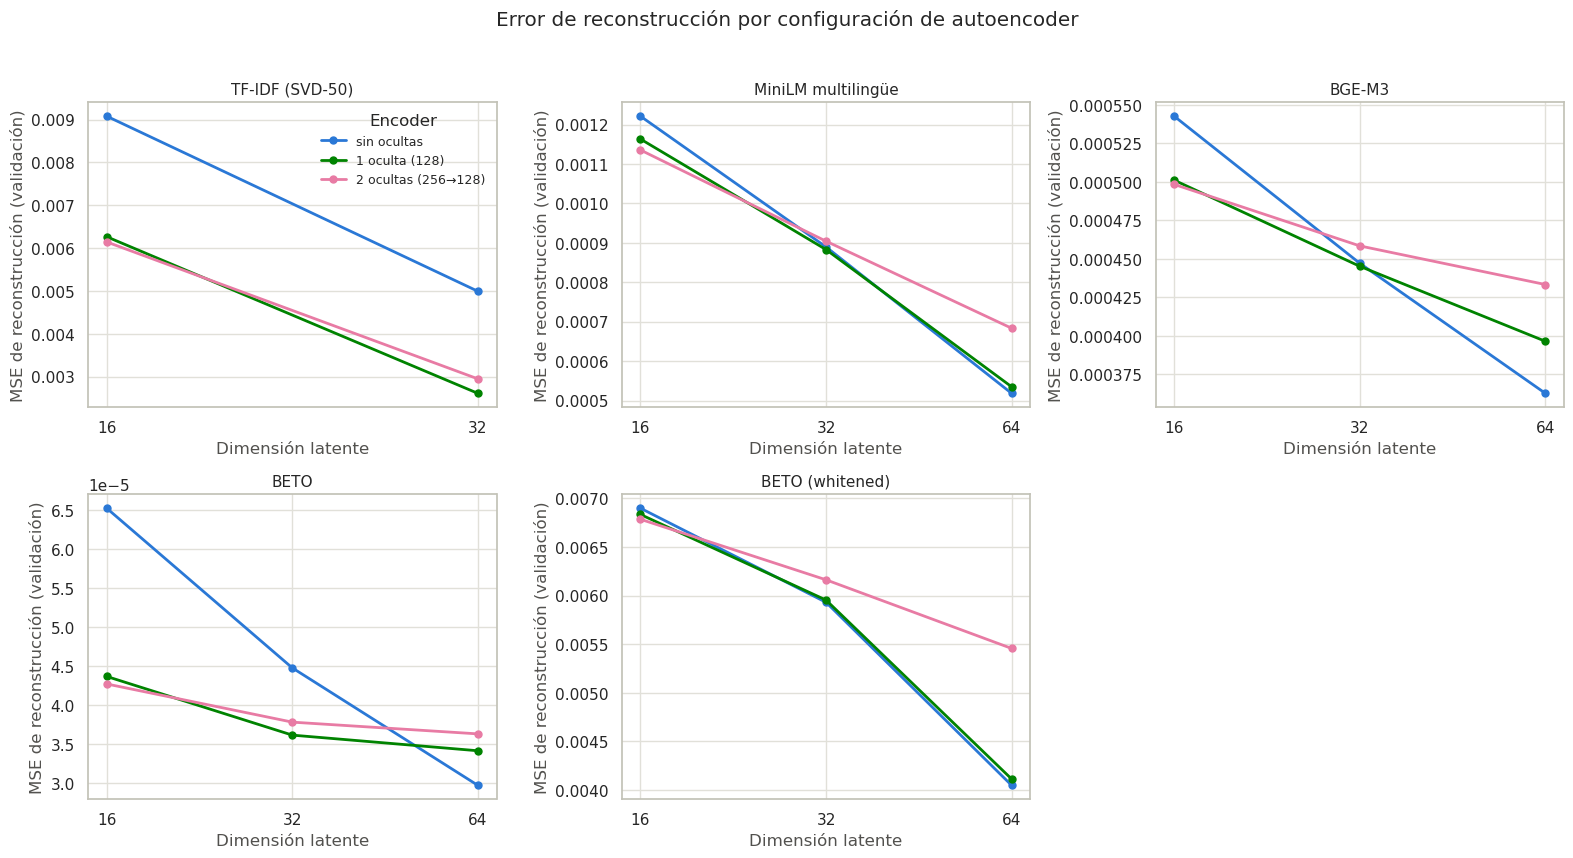

In [6]:
fig, axes = rejilla(len(embeddings), alto=4.2)
for ax, nombre in zip(axes, embeddings):
    sub = pruebas_ae[pruebas_ae["tecnica"] == nombre]
    for color, (etiqueta_arq, g) in zip(PALETA, sub.groupby("arquitectura", sort=False)):
        ax.plot(g["dim_latente"], g["mse_val"], marker="o", markersize=5,
                linewidth=2, color=color, label=etiqueta_arq)
    ax.set_title(nombre, fontsize=11)
    ax.set_xlabel("Dimensión latente")
    ax.set_ylabel("MSE de reconstrucción (validación)")
    ax.set_xscale("log", base=2)
    ax.set_xticks(sorted(sub["dim_latente"].unique()))
    ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())
axes[0].legend(frameon=False, fontsize=9, title="Encoder")
plt.suptitle("Error de reconstrucción por configuración de autoencoder", y=1.02)
plt.tight_layout()
plt.show()


## Selección del mejor autoencoder y proyección al espacio latente

Se toma, por técnica, la configuración con menor MSE de validación; el encoder de ese
modelo proyecta **toda** la muestra al espacio latente y el resultado se L2-normaliza
(igual que los embeddings originales) para que Ward opere sobre distancias comparables
a coseno.


In [7]:
mejores_ae = (pruebas_ae.loc[pruebas_ae.groupby("tecnica", sort=False)["mse_val"].idxmin()]
              .set_index("tecnica"))
display(mejores_ae.round(6))

embeddings_lat = {}
for nombre, fila in mejores_ae.iterrows():
    modelo = modelos_ae[(nombre, fila["arquitectura"], fila["dim_latente"])]
    with torch.no_grad():
        latente = modelo.encoder(
            torch.tensor(embeddings[nombre], dtype=torch.float32, device=DEVICE)
        ).cpu().numpy()
    embeddings_lat[nombre] = normalize(latente)
    print(f"{nombre}: {embeddings[nombre].shape[1]} dims → latente {latente.shape[1]} "
          f"({fila['arquitectura']}, MSE val {fila['mse_val']:.6f})")


,arquitectura,dim_latente,mse_val
tecnica,,,
TF-IDF (SVD-50),1 oculta (128),32,0.002609
MiniLM multilingüe,sin ocultas,64,0.000518
BGE-M3,sin ocultas,64,0.000363
BETO,sin ocultas,64,0.000030
BETO (whitened),sin ocultas,64,0.004048


TF-IDF (SVD-50): 50 dims → latente 32 (1 oculta (128), MSE val 0.002609)
MiniLM multilingüe: 384 dims → latente 64 (sin ocultas, MSE val 0.000518)
BGE-M3: 1024 dims → latente 64 (sin ocultas, MSE val 0.000363)
BETO: 768 dims → latente 64 (sin ocultas, MSE val 0.000030)
BETO (whitened): 128 dims → latente 64 (sin ocultas, MSE val 0.004048)


## Linkage jerárquico (Ward) y dendrogramas sobre el espacio latente

Se construye la jerarquía completa con `scipy.cluster.hierarchy.linkage(method="ward")`
sobre los embeddings latentes y se reporta la **correlación cofenética** de cada árbol.
Los dendrogramas se truncan a los últimos 30 merges para legibilidad.


In [8]:
from scipy.cluster.hierarchy import cophenet, dendrogram, fcluster, linkage
from scipy.spatial.distance import pdist

linkages, cofeneticas = {}, {}
for nombre, emb in embeddings_lat.items():
    dist = pdist(emb)
    Z = linkage(emb, method="ward")
    linkages[nombre] = Z
    cofeneticas[nombre], _ = cophenet(Z, dist)
    print(f"{nombre}: correlación cofenética = {cofeneticas[nombre]:.3f}")


TF-IDF (SVD-50): correlación cofenética = 0.453
MiniLM multilingüe: correlación cofenética = 0.300
BGE-M3: correlación cofenética = 0.307
BETO: correlación cofenética = 0.371
BETO (whitened): correlación cofenética = 0.165


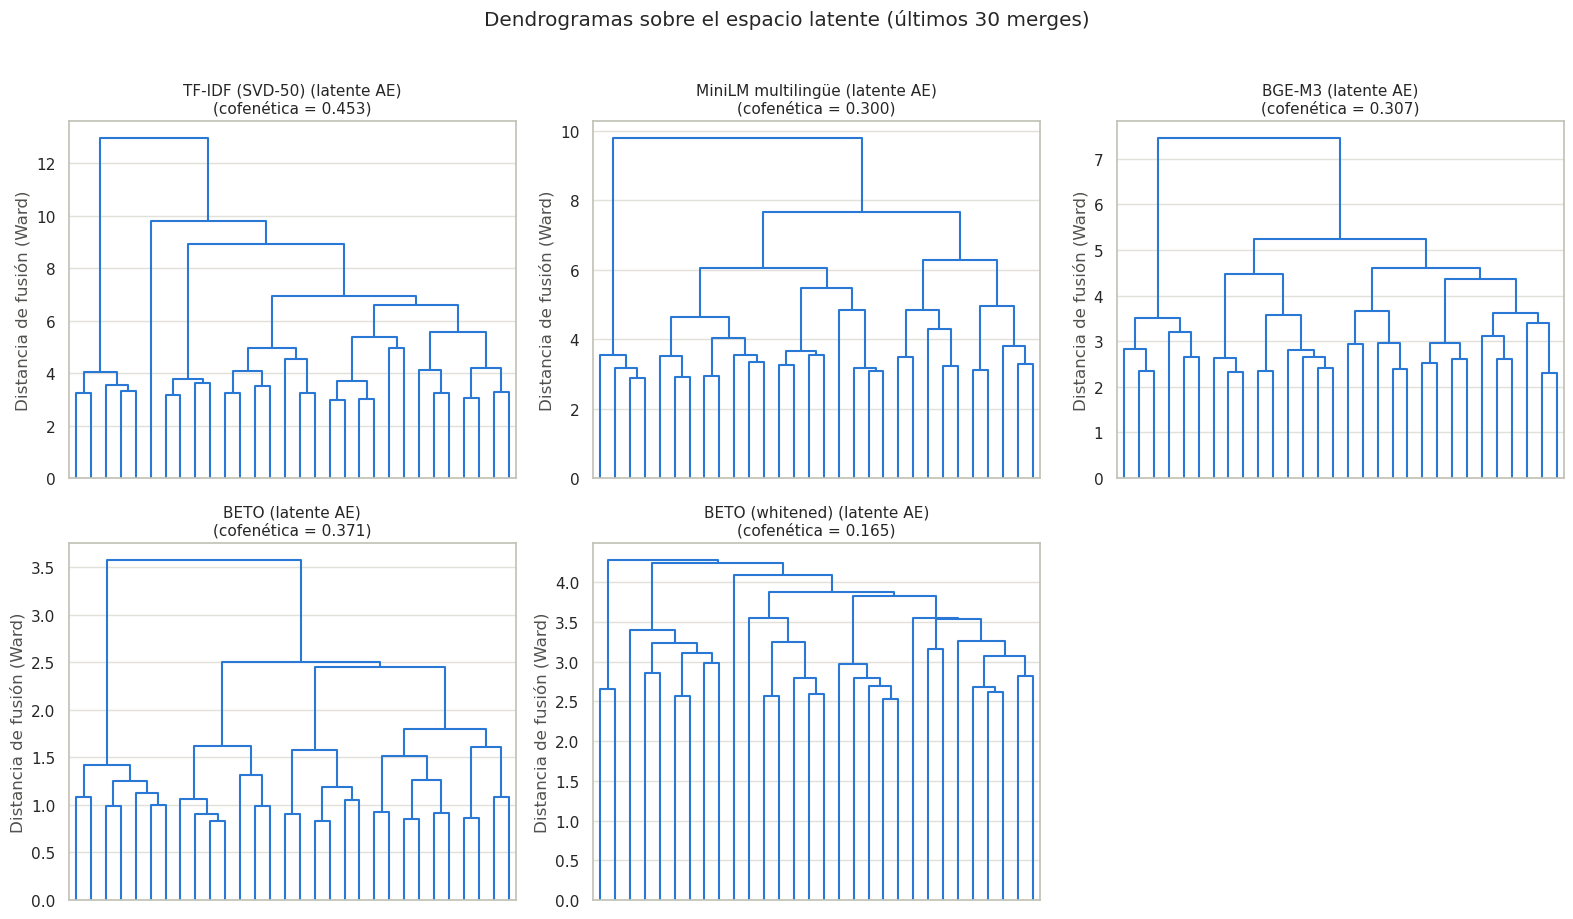

In [9]:
fig, axes = rejilla(len(embeddings_lat))
for ax, (nombre, Z) in zip(axes, linkages.items()):
    dendrogram(Z, truncate_mode="lastp", p=30, ax=ax, no_labels=True,
               color_threshold=0, above_threshold_color="#2a78d6")
    ax.set_title(f"{nombre} (latente AE)\n(cofenética = {cofeneticas[nombre]:.3f})", fontsize=11)
    ax.set_ylabel("Distancia de fusión (Ward)")
    ax.set_xticks([])
plt.suptitle("Dendrogramas sobre el espacio latente (últimos 30 merges)", y=1.02)
plt.tight_layout()
plt.show()


## Métricas no supervisadas por número de clústeres

Para cada técnica se corta el dendrograma en k = 2…15 y se calculan silhouette
(con distancia coseno), Calinski-Harabasz y Davies-Bouldin, todo sobre el espacio latente.


In [10]:
from sklearn.metrics import (calinski_harabasz_score, davies_bouldin_score,
                             silhouette_score)

RANGO_K = range(2, 16)
filas = []
etiquetas_por_k = {}
for nombre, emb in embeddings_lat.items():
    Z = linkages[nombre]
    for k in RANGO_K:
        etiquetas = fcluster(Z, t=k, criterion="maxclust")
        etiquetas_por_k[(nombre, k)] = etiquetas
        filas.append({
            "tecnica": nombre,
            "k": k,
            "silhouette": silhouette_score(emb, etiquetas, metric="cosine"),
            "calinski_harabasz": calinski_harabasz_score(emb, etiquetas),
            "davies_bouldin": davies_bouldin_score(emb, etiquetas),
        })

metricas = pd.DataFrame(filas)
metricas.head()


,tecnica,k,silhouette,calinski_harabasz,davies_bouldin
0,TF-IDF (SVD-50),2,0.160020,142.183518,2.318821
1,TF-IDF (SVD-50),3,0.160294,118.196869,2.000231
2,TF-IDF (SVD-50),4,0.151803,107.456913,2.372589
3,TF-IDF (SVD-50),5,0.140914,94.745692,3.175933
4,TF-IDF (SVD-50),6,0.145387,86.631578,3.104890


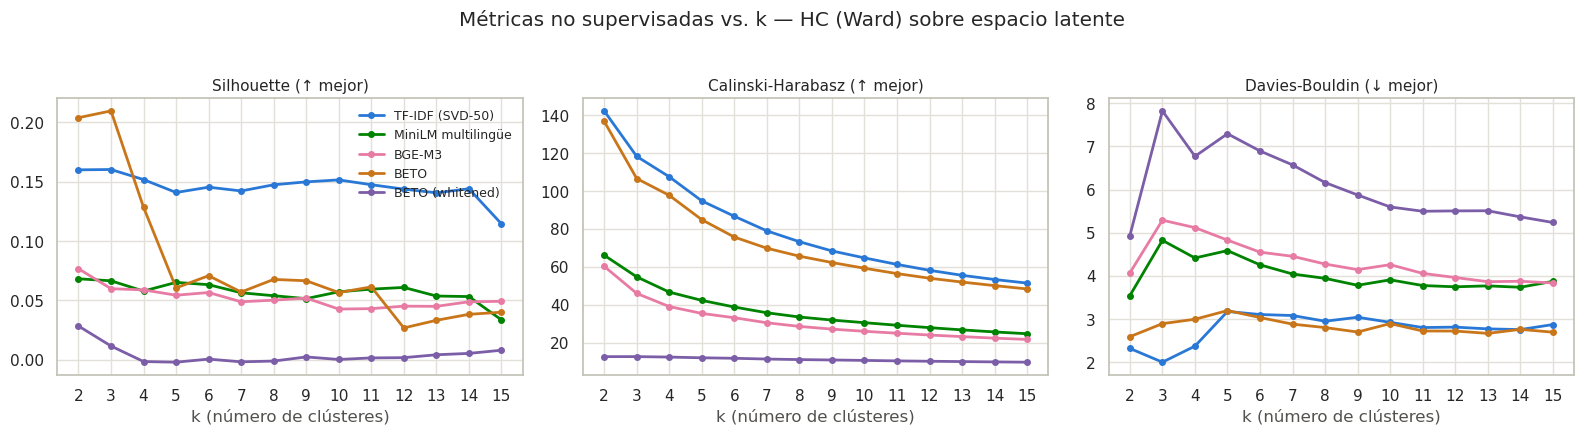

In [11]:
COLORES_TEC = dict(zip(embeddings_lat, PALETA))
config_metricas = [("silhouette", "Silhouette (↑ mejor)"),
                   ("calinski_harabasz", "Calinski-Harabasz (↑ mejor)"),
                   ("davies_bouldin", "Davies-Bouldin (↓ mejor)")]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
for ax, (col, titulo) in zip(axes, config_metricas):
    for nombre in embeddings_lat:
        serie = metricas[metricas["tecnica"] == nombre]
        ax.plot(serie["k"], serie[col], marker="o", markersize=4, linewidth=2,
                color=COLORES_TEC[nombre], label=nombre)
    ax.set_xlabel("k (número de clústeres)")
    ax.set_title(titulo, fontsize=11)
    ax.set_xticks(list(RANGO_K))
axes[0].legend(frameon=False, fontsize=9)
plt.suptitle("Métricas no supervisadas vs. k — HC (Ward) sobre espacio latente", y=1.03)
plt.tight_layout()
plt.show()


## Resumen: mejor k por técnica

Se elige el k que maximiza silhouette y se reportan las tres métricas en ese corte,
junto con el tamaño de los clústeres resultantes.


In [12]:
mejores = (metricas.loc[metricas.groupby("tecnica")["silhouette"].idxmax()]
           .set_index("tecnica").round(3))
mejores["cofenetica"] = pd.Series(cofeneticas).round(3)
mejores


,k,silhouette,calinski_harabasz,davies_bouldin,cofenetica
tecnica,,,,,
BETO,3,0.210,106.536,2.894,0.371
BETO (whitened),2,0.028,12.633,4.935,0.165
BGE-M3,2,0.077,60.243,4.070,0.307
MiniLM multilingüe,2,0.068,66.093,3.543,0.300
TF-IDF (SVD-50),3,0.160,118.197,2.000,0.453


In [13]:
for nombre in embeddings_lat:
    k = int(mejores.loc[nombre, "k"])
    tam = np.bincount(etiquetas_por_k[(nombre, k)])[1:].tolist()
    print(f"{nombre} (k={k}): tamaños de clúster = {sorted(tam, reverse=True)}")


TF-IDF (SVD-50) (k=3): tamaños de clúster = [1167, 270, 75]
MiniLM multilingüe (k=2): tamaños de clúster = [1236, 276]
BGE-M3 (k=2): tamaños de clúster = [1180, 332]
BETO (k=3): tamaños de clúster = [1029, 317, 166]
BETO (whitened) (k=2): tamaños de clúster = [1426, 86]


## Métricas supervisadas por número de clústeres (sección como label)

Se usa la sección del artículo (`seccion`) como etiqueta de referencia externa y se
evalúan los cortes k = 2…15 con ARI, AMI, homogeneidad, completitud y V-measure.
Las secciones son muy granulares (cientos de valores distintos entre periódicos),
por lo que se privilegian las métricas ajustadas por azar (ARI, AMI), que no
premian la mera fragmentación.

In [14]:
from sklearn.metrics import (adjusted_mutual_info_score, adjusted_rand_score,
                             completeness_score, homogeneity_score, v_measure_score)

secciones = muestra["seccion"].fillna("(sin sección)").to_numpy()
print(f"Secciones distintas en la submuestra: {pd.Series(secciones).nunique()}")

filas = []
for nombre in embeddings_lat:
    for k in RANGO_K:
        etiquetas = etiquetas_por_k[(nombre, k)]
        filas.append({
            "tecnica": nombre,
            "k": k,
            "ari": adjusted_rand_score(secciones, etiquetas),
            "ami": adjusted_mutual_info_score(secciones, etiquetas),
            "homogeneidad": homogeneity_score(secciones, etiquetas),
            "completitud": completeness_score(secciones, etiquetas),
            "v_measure": v_measure_score(secciones, etiquetas),
        })

metricas_sup = pd.DataFrame(filas)
metricas_sup.head()

Secciones distintas en la submuestra: 213


,tecnica,k,ari,ami,homogeneidad,completitud,v_measure
0,TF-IDF (SVD-50),2,0.019624,0.121564,0.084465,0.678686,0.150233
1,TF-IDF (SVD-50),3,0.021423,0.133866,0.102713,0.589847,0.174959
2,TF-IDF (SVD-50),4,0.028928,0.157621,0.135241,0.514123,0.214150
3,TF-IDF (SVD-50),5,0.064688,0.189944,0.178916,0.477968,0.260369
4,TF-IDF (SVD-50),6,0.085932,0.195773,0.201243,0.444745,0.277101


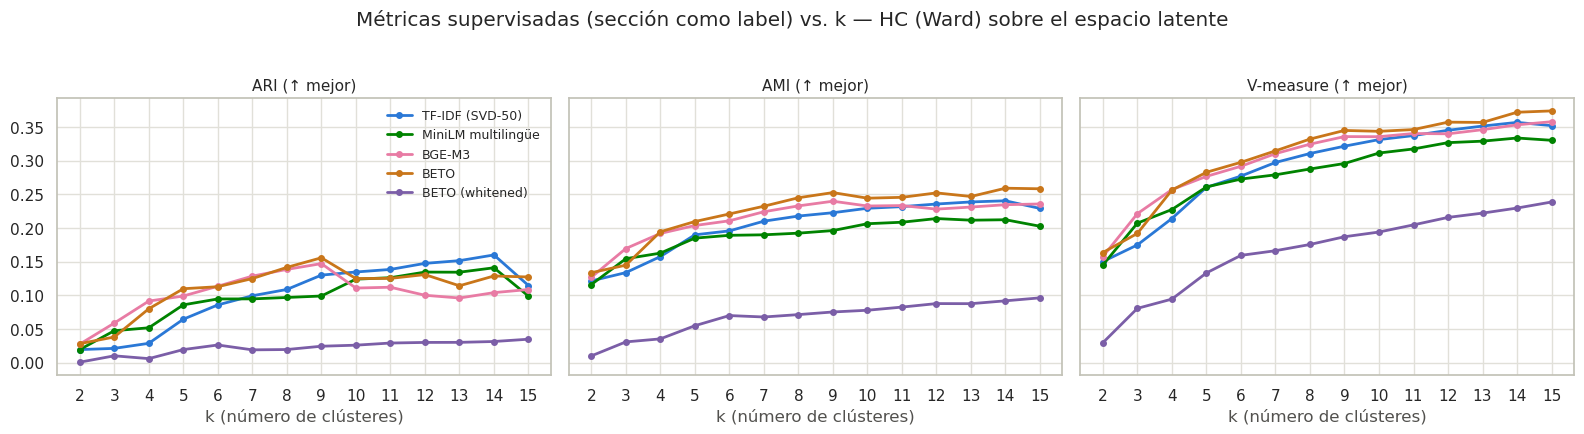

Métricas supervisadas en el k óptimo (por silhouette) de cada técnica:


,k,ari,ami,homogeneidad,completitud,v_measure
tecnica,,,,,,
TF-IDF (SVD-50),3,0.021,0.134,0.103,0.590,0.175
MiniLM multilingüe,2,0.020,0.116,0.082,0.649,0.145
BGE-M3,2,0.028,0.127,0.090,0.643,0.158
BETO,3,0.038,0.145,0.117,0.531,0.192
BETO (whitened),2,0.001,0.010,0.016,0.272,0.030


In [15]:
config_sup = [("ari", "ARI (↑ mejor)"), ("ami", "AMI (↑ mejor)"),
              ("v_measure", "V-measure (↑ mejor)")]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.2), sharey=True)
for ax, (col, titulo) in zip(axes, config_sup):
    for nombre in embeddings_lat:
        serie = metricas_sup[metricas_sup["tecnica"] == nombre]
        ax.plot(serie["k"], serie[col], marker="o", markersize=4, linewidth=2,
                color=COLORES_TEC[nombre], label=nombre)
    ax.set_xlabel("k (número de clústeres)")
    ax.set_title(titulo, fontsize=11)
    ax.set_xticks(list(RANGO_K))
axes[0].legend(frameon=False, fontsize=9)
plt.suptitle("Métricas supervisadas (sección como label) vs. k — HC (Ward) sobre el espacio latente", y=1.03)
plt.tight_layout()
plt.show()

resumen_sup = (metricas_sup.merge(mejores.reset_index()[["tecnica", "k"]].astype({"k": int}),
                                  on=["tecnica", "k"])
               .set_index("tecnica").round(3))
print("Métricas supervisadas en el k óptimo (por silhouette) de cada técnica:")
resumen_sup

## Árboles completos coloreados por el corte óptimo

Dendrograma **completo** (todas las hojas) de cada técnica sobre el espacio latente.
La línea punteada marca la altura de corte que produce el mejor k según silhouette;
las ramas por debajo de esa altura se colorean por clúster resultante.


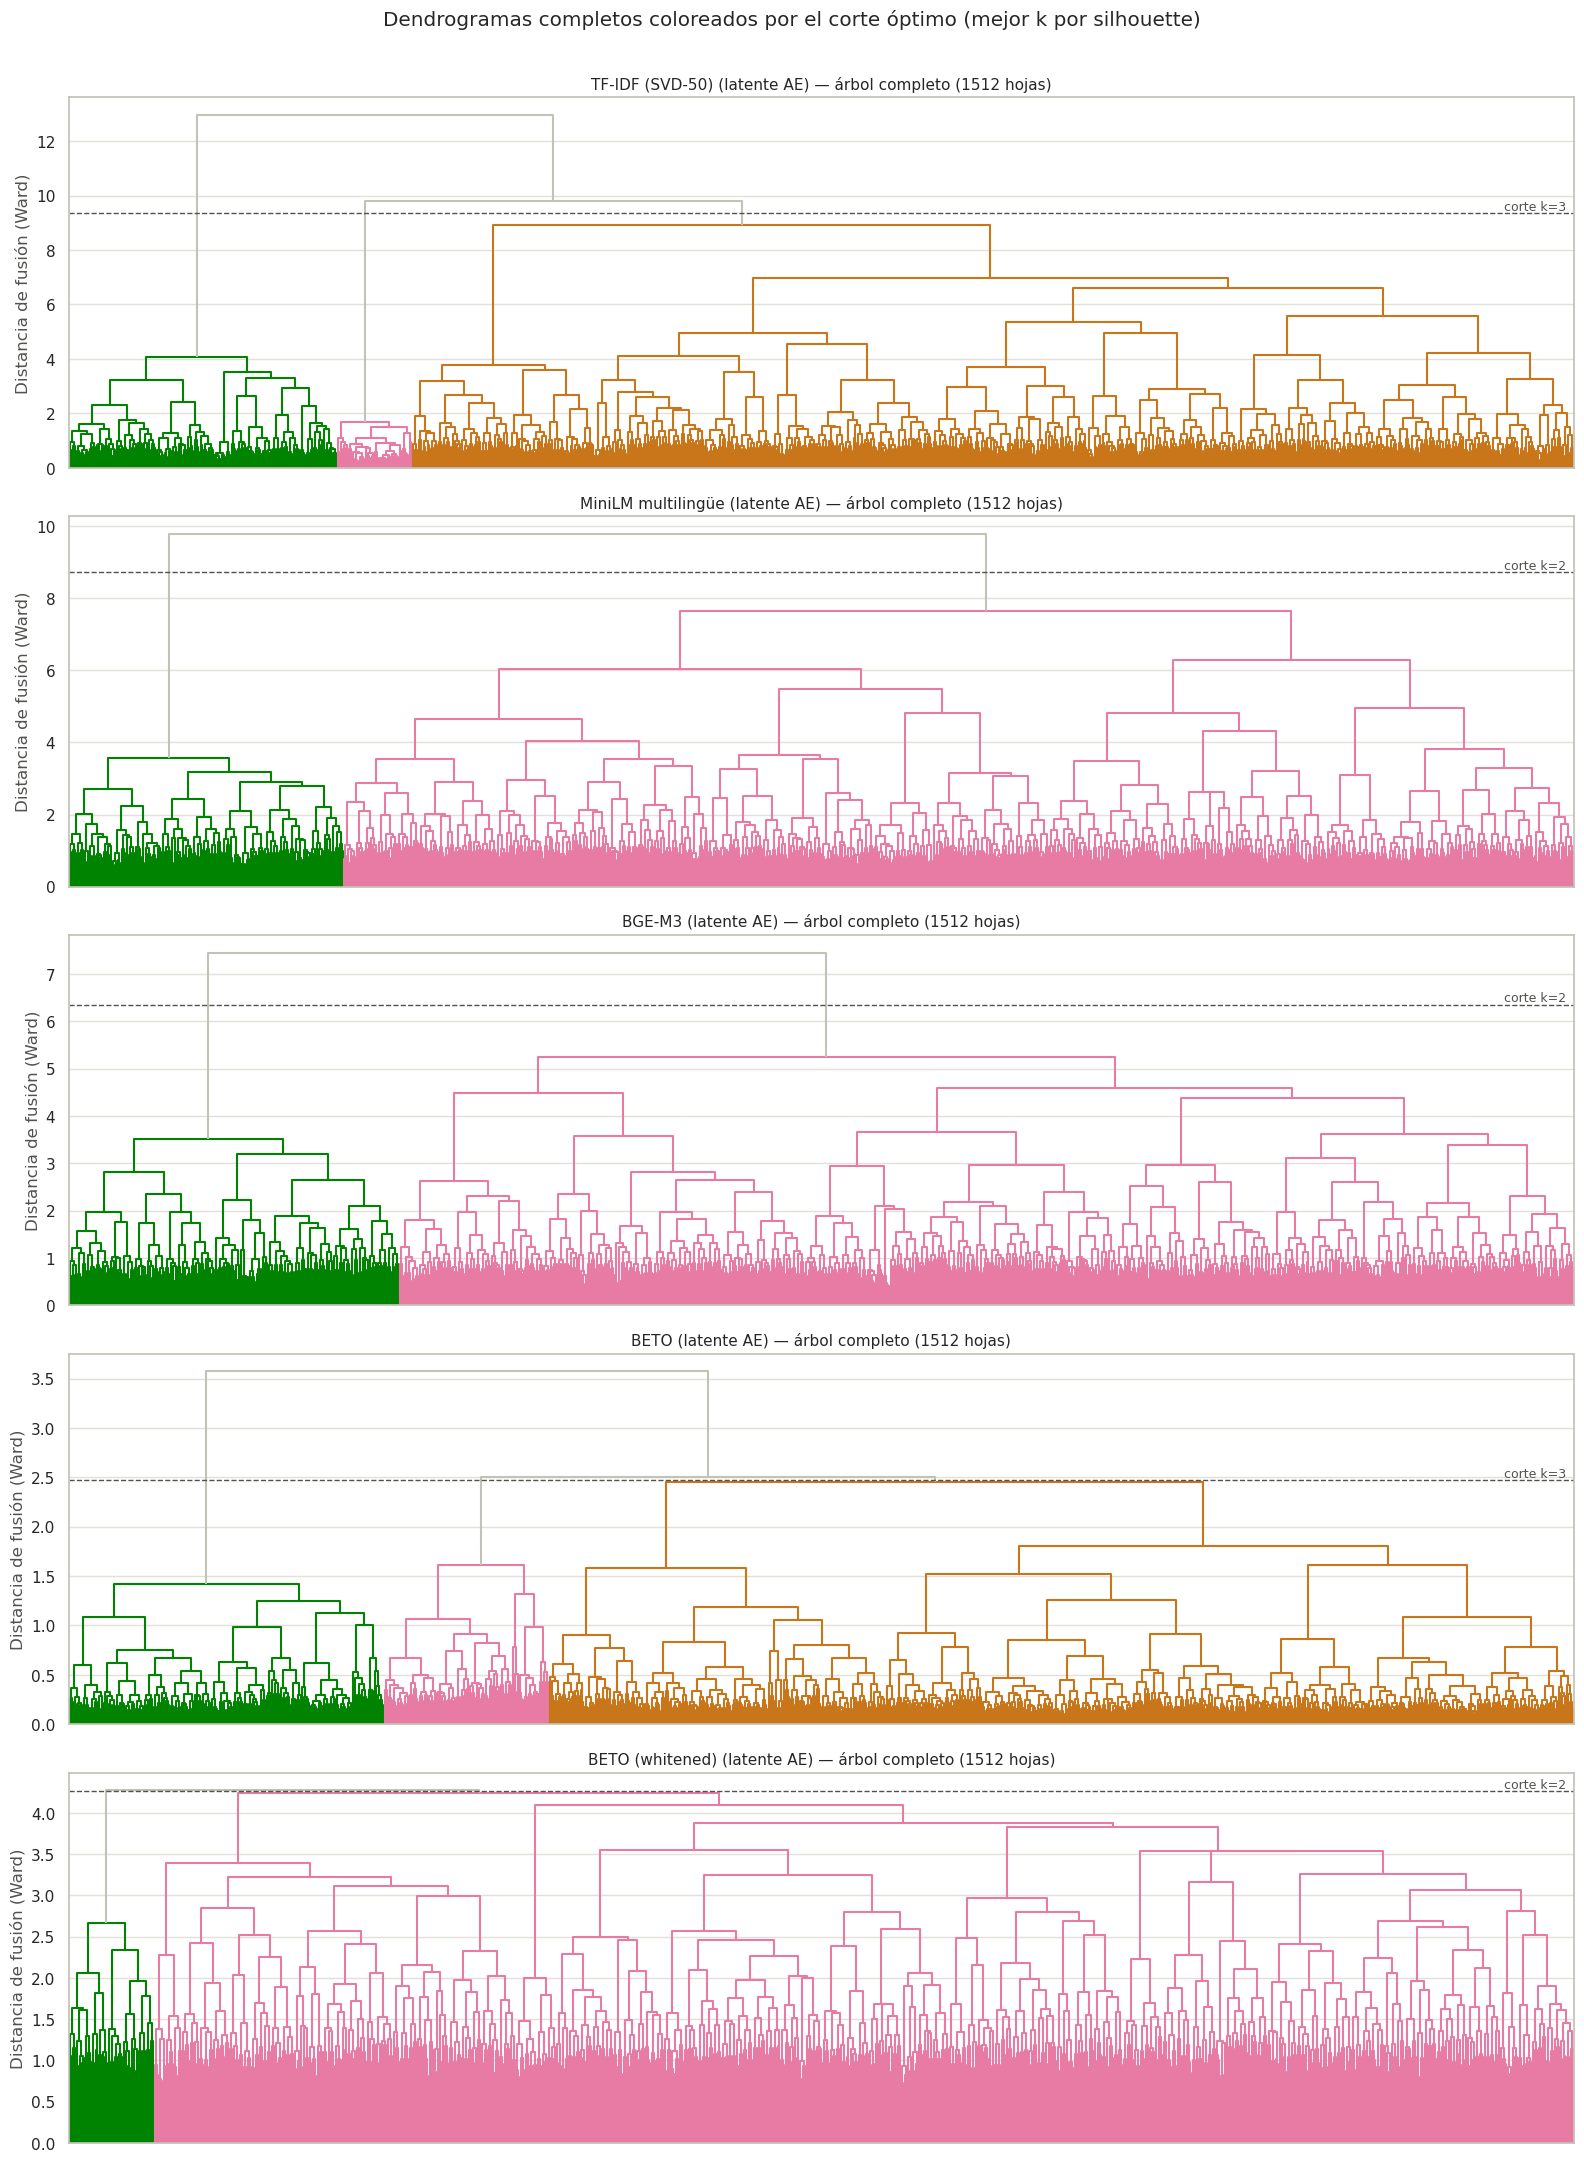

In [16]:
fig, axes = plt.subplots(len(embeddings_lat), 1, figsize=(16, 4.3 * len(embeddings_lat)))
for ax, (nombre, Z) in zip(np.atleast_1d(axes).ravel(), linkages.items()):
    k = int(mejores.loc[nombre, "k"])
    # Altura de corte: punto medio entre los merges que dejan k y k-1 clústeres
    umbral = (Z[-k, 2] + Z[-(k - 1), 2]) / 2 if k > 1 else Z[-1, 2] * 1.05
    dendrogram(Z, ax=ax, no_labels=True, color_threshold=umbral,
               above_threshold_color="#c3c2b7")
    ax.axhline(umbral, color="#52514e", linestyle="--", linewidth=1)
    ax.text(0.995, umbral, f" corte k={k}", transform=ax.get_yaxis_transform(),
            ha="right", va="bottom", fontsize=9, color="#52514e")
    ax.set_title(f"{nombre} (latente AE) — árbol completo ({Z.shape[0] + 1} hojas)", fontsize=11)
    ax.set_ylabel("Distancia de fusión (Ward)")
    ax.set_xticks([])
plt.suptitle("Dendrogramas completos coloreados por el corte óptimo (mejor k por silhouette)", y=1.005)
plt.tight_layout()
plt.show()


## Visualización de los cortes óptimos (t-SNE)

Proyección t-SNE 2D de cada espacio latente (los latentes ya tienen ≤ 64 dims, así que
no se aplica reducción previa) coloreada por el clúster jerárquico en el mejor k.


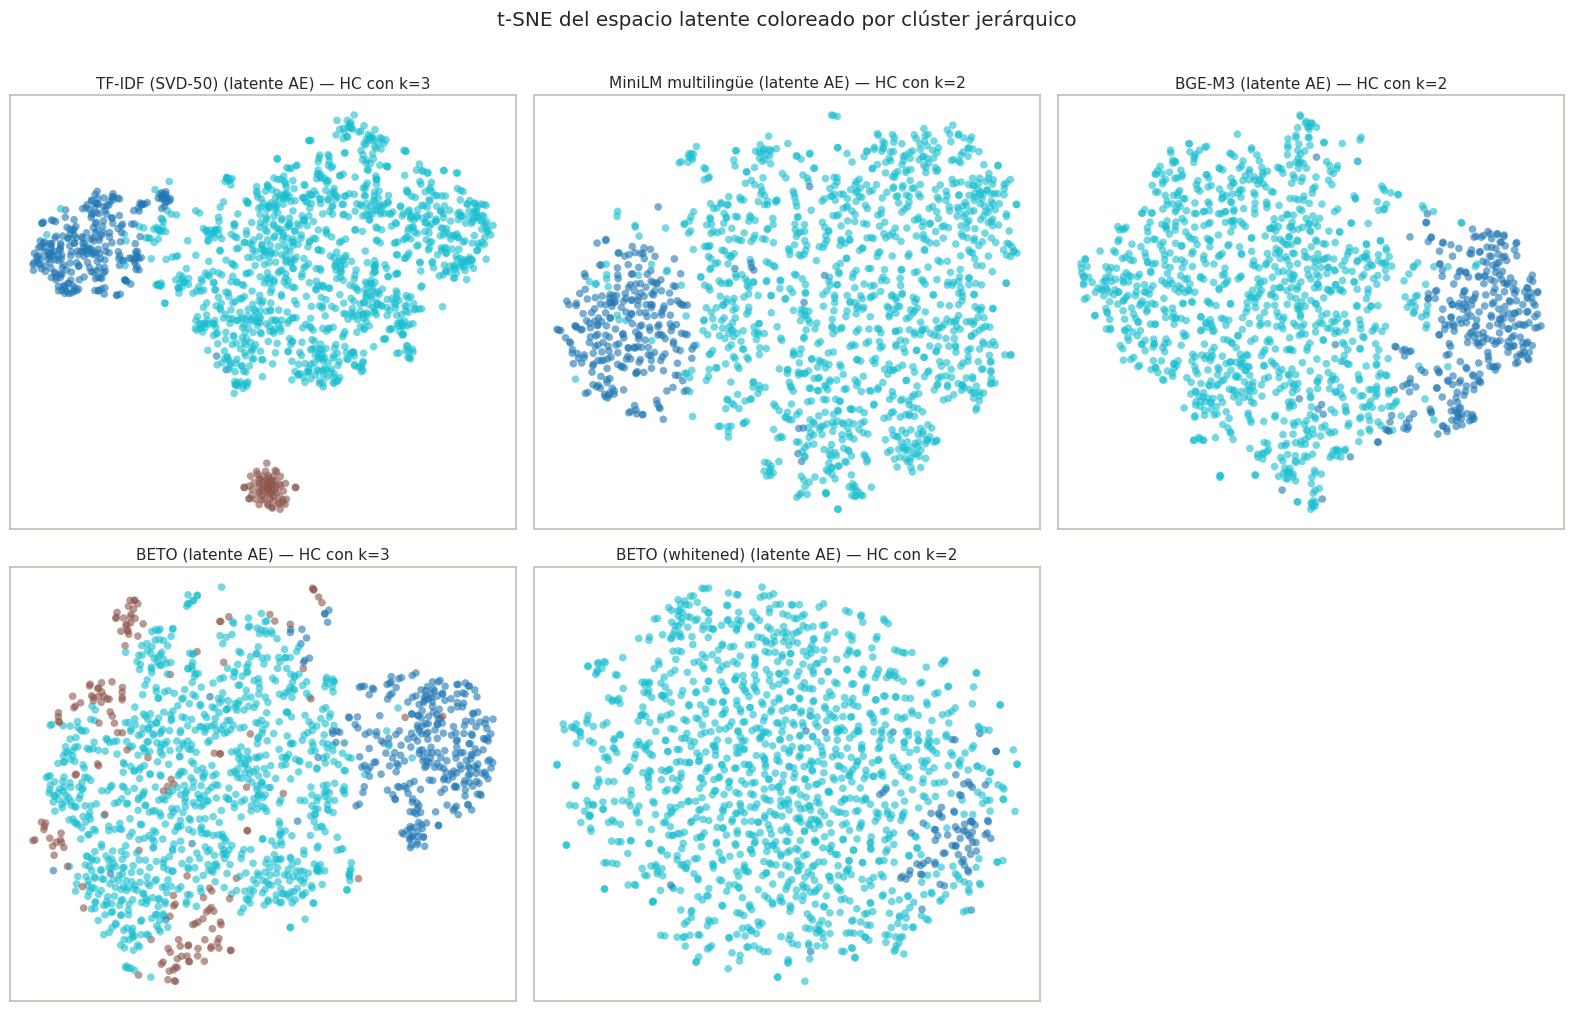

In [17]:
from sklearn.manifold import TSNE

fig, axes = rejilla(len(embeddings_lat), alto=5)
for ax, (nombre, emb) in zip(axes, embeddings_lat.items()):
    xy = TSNE(n_components=2, init="pca", perplexity=30, max_iter=1000,
              random_state=RANDOM_STATE).fit_transform(emb)
    k = int(mejores.loc[nombre, "k"])
    etiquetas = etiquetas_por_k[(nombre, k)]
    ax.scatter(xy[:, 0], xy[:, 1], c=etiquetas, cmap="tab10", s=30, alpha=0.6, linewidths=0)
    ax.set_title(f"{nombre} (latente AE) — HC con k={k}", fontsize=11)
    ax.set_xticks([])
    ax.set_yticks([])
plt.suptitle("t-SNE del espacio latente coloreado por clúster jerárquico", y=1.01)
plt.tight_layout()
plt.show()


## Títulos descriptivos por clúster (DeepSeek vía vLLM)

Para cada clúster del corte óptimo se toma una **muestra aleatoria de 10 artículos**
(título + inicio del texto) y se pide a `deepseek-ai/DeepSeek-V4-Flash` (servidor H200,
cliente de `src/llm_clients`) un **título descriptivo corto** del tema dominante.
**Requiere VPN GlobalProtect activa.**

Nota: DeepSeek es un modelo de razonamiento — consume parte del presupuesto de
`max_tokens` en el campo `reasoning` antes de emitir `content`, por eso se usa un
límite generoso aunque la respuesta esperada sea corta.


In [18]:
from src.llm_clients import get_chat_client, load_config

config = load_config()
cliente_chat = get_chat_client(config)
N_EJEMPLOS = 10

PROMPT_TITULO = (
    "Eres un analista de prensa ecuatoriana. A continuación tienes una muestra de "
    "artículos (título y primeras líneas) que pertenecen a un mismo clúster temático "
    "obtenido por clustering no supervisado.\n\n{ejemplos}\n\n"
    "Escribe UN solo título descriptivo en español (máximo 10 palabras) que resuma el "
    "tema dominante del clúster. Si los temas son heterogéneos, dilo en el título "
    "(p. ej. 'Actualidad general: política, deportes y sucesos'). "
    "Responde únicamente con el título, sin comillas ni explicaciones."
)


def titular_cluster(indices: np.ndarray) -> str:
    """Pide a DeepSeek un título descriptivo para los artículos indicados."""
    ejemplos = "\n".join(
        f"- {muestra.loc[i, 'titulo'] or '(sin título)'}: "
        f"{muestra.loc[i, 'texto_norm'][:200]}…"
        for i in indices
    )
    respuesta = cliente_chat.chat.completions.create(
        model=config.chat_model,
        messages=[{"role": "user", "content": PROMPT_TITULO.format(ejemplos=ejemplos)}],
        temperature=0.3,
        max_tokens=2000,  # modelo de razonamiento: reserva presupuesto para 'reasoning'
    )
    contenido = respuesta.choices[0].message.content
    return contenido.strip().strip('"') if contenido else "(respuesta vacía)"


In [19]:
from tqdm.auto import tqdm

rng = np.random.default_rng(RANDOM_STATE)
filas = []
for nombre in embeddings_lat:
    k = int(mejores.loc[nombre, "k"])
    etiquetas = etiquetas_por_k[(nombre, k)]
    for c in tqdm(range(1, k + 1), desc=f"{nombre} (k={k})"):
        indices = np.flatnonzero(etiquetas == c)
        seleccion = rng.choice(indices, size=min(N_EJEMPLOS, len(indices)), replace=False)
        filas.append({
            "tecnica": nombre,
            "cluster": c,
            "n_articulos": len(indices),
            "titulo_deepseek": titular_cluster(seleccion),
            "ejemplos": " | ".join(muestra.loc[seleccion[:3], "titulo"].fillna("(sin título)")),
        })

titulos_clusters = pd.DataFrame(filas)
with pd.option_context("display.max_colwidth", 120):
    display(titulos_clusters)


TF-IDF (SVD-50) (k=3):   0%|          | 0/3 [00:00<?, ?it/s]

MiniLM multilingüe (k=2):   0%|          | 0/2 [00:00<?, ?it/s]

BGE-M3 (k=2):   0%|          | 0/2 [00:00<?, ?it/s]

BETO (k=3):   0%|          | 0/3 [00:00<?, ?it/s]

BETO (whitened) (k=2):   0%|          | 0/2 [00:00<?, ?it/s]

,tecnica,cluster,n_articulos,titulo_deepseek,ejemplos
0,TF-IDF (SVD-50),1,270,Deportes variados y lotería,Lotería | La Tricolor Y El Premio Millonario Por Clasificar | Sudamericano De Básquet Damas En El Abel Jiménez
1,TF-IDF (SVD-50),2,75,"Actualidad general: política, deportes y sucesos","Cer­ve­cera logra ganar varias cate­go­rías | BRASIL, OCTUBRE | La tie­rra se abre y engu­lle sin miras"
2,TF-IDF (SVD-50),3,1167,"Noticias diversas: crimen, política y actualidad",Ingresan A Casa Y Matan A Un Hombre | Argumento Falaz | Unes Logra Mayor Número De Asambleístas
3,MiniLM multilingüe,1,276,Deportes: fútbol y automovilismo,Estas Son Las Convocadas De La Selección Femenina De Ecuador Para Los Amistosos Ante Uruguay En Quito | Lloris Y Her...
4,MiniLM multilingüe,2,1236,"Actualidad ecuatoriana: sucesos, cultura, política y metro","El Dolor De Venezuela | ‘Me Dijeron Que, Si No Pago, A Mi Mamá La Van A Matar’: Contador Recibe Amenazas | ¿Qué Escu..."
5,BGE-M3,1,332,"Deportes y actualidad: fútbol, olímpicos y televisión","Dt Ariel Holan Explicó La Razón De Darle Titularidad Al Arquero Víctor Mendoza | Héroes Olímpicos Y Paralímpicos, En..."
6,BGE-M3,2,1180,"Actualidad general: política, religión, tecnología y sucesos",Binomio Arauz-Rabascall Queda En Firme Para Las Elecciones De 2021 | California Pondrá Fin A Las Bolsas De Plástico ...
7,BETO,1,317,"Actualidad deportiva: fútbol, baloncesto e hípica","Hjulmand: ""Lo Que Pasó Con Eriksen Fue Una Experiencia Traumática"" | El Estadio Lusail, El Imponente Legado Que Deja..."
8,BETO,2,166,"Actualidad ecuatoriana: política, seguridad y sociedad",Jan Topic Tiene Su Reemplazo: Wilson Gómez Es El Candidato De Suma Para La Presidencia De La República | Le roba­ron...
9,BETO,3,1029,"Actualidad general: política, deportes y sucesos",Los Miles De Compras Que Se Hicieron En Emergencia | España Usa Tecnología De F1 Para El Calor | India Declara Día D...


## Análisis de subclusters (espacio latente)

Cada clúster del corte óptimo con al menos `MIN_SUBCLUSTER` artículos se subdivide con
un nuevo linkage de Ward sobre sus miembros — equivalente al subárbol del dendrograma
global bajo la altura de corte, ya que por debajo de ella los merges de Ward solo
involucran puntos del mismo clúster. El número de subclusters se elige en 2…6
maximizando silhouette (coseno) **dentro** del clúster; los clústeres con menos
artículos que el mínimo se dejan sin subdividir.

In [20]:
MIN_SUBCLUSTER = 40
RANGO_SUB_K = range(2, 7)

subclusters = {}  # (tecnica, cluster) -> (indices globales, etiquetas de subcluster)
filas = []
for nombre, emb in embeddings_lat.items():
    k = int(mejores.loc[nombre, "k"])
    etiquetas = etiquetas_por_k[(nombre, k)]
    for c in range(1, k + 1):
        indices = np.flatnonzero(etiquetas == c)
        if len(indices) < MIN_SUBCLUSTER:
            print(f"{nombre} — clúster {c}: {len(indices)} artículos, no se subdivide")
            continue
        Z_sub = linkage(emb[indices], method="ward")
        mejor_sil, mejor_sub = -np.inf, None
        for sub_k in RANGO_SUB_K:
            etiquetas_sub = fcluster(Z_sub, t=sub_k, criterion="maxclust")
            sil = silhouette_score(emb[indices], etiquetas_sub, metric="cosine")
            if sil > mejor_sil:
                mejor_sil, mejor_sub = sil, etiquetas_sub
        subclusters[(nombre, c)] = (indices, mejor_sub)
        filas.append({
            "tecnica": nombre,
            "cluster": c,
            "n_articulos": len(indices),
            "sub_k": int(mejor_sub.max()),
            "silhouette_sub": round(mejor_sil, 3),
            "tamanios_sub": sorted(np.bincount(mejor_sub)[1:].tolist(), reverse=True),
        })

resumen_subclusters = pd.DataFrame(filas)
resumen_subclusters

,tecnica,cluster,n_articulos,sub_k,silhouette_sub,tamanios_sub
0,TF-IDF (SVD-50),1,270,6,0.160,"[88, 58, 42, 38, 27, 17]"
1,TF-IDF (SVD-50),2,75,2,0.398,"[64, 11]"
2,TF-IDF (SVD-50),3,1167,2,0.133,"[984, 183]"
3,MiniLM multilingüe,1,276,3,0.058,"[122, 93, 61]"
4,MiniLM multilingüe,2,1236,2,0.056,"[709, 527]"
5,BGE-M3,1,332,5,0.081,"[80, 66, 66, 66, 54]"
6,BGE-M3,2,1180,2,0.044,"[773, 407]"
7,BETO,1,317,3,0.129,"[143, 91, 83]"
8,BETO,2,166,2,0.327,"[129, 37]"
9,BETO,3,1029,2,0.169,"[691, 338]"


### Títulos descriptivos por subcluster (DeepSeek vía vLLM)

Se reutiliza `titular_cluster` para pedir a DeepSeek un título por subcluster (misma
muestra aleatoria de hasta 10 artículos). La tabla incluye el título del clúster padre
para leer la jerarquía temática completa. **Requiere VPN GlobalProtect activa.**

In [21]:
filas = []
for (nombre, c), (indices, etiquetas_sub) in subclusters.items():
    titulo_padre = titulos_clusters.query(
        "tecnica == @nombre and cluster == @c")["titulo_deepseek"].iloc[0]
    for s in tqdm(range(1, int(etiquetas_sub.max()) + 1), desc=f"{nombre} — clúster {c}"):
        indices_sub = indices[etiquetas_sub == s]
        seleccion = rng.choice(indices_sub, size=min(N_EJEMPLOS, len(indices_sub)), replace=False)
        filas.append({
            "tecnica": nombre,
            "cluster": c,
            "titulo_cluster": titulo_padre,
            "subcluster": s,
            "n_articulos": len(indices_sub),
            "titulo_deepseek": titular_cluster(seleccion),
            "ejemplos": " | ".join(muestra.loc[seleccion[:3], "titulo"].fillna("(sin título)")),
        })

titulos_subclusters = pd.DataFrame(filas)
with pd.option_context("display.max_colwidth", 100):
    display(titulos_subclusters)

TF-IDF (SVD-50) — clúster 1:   0%|          | 0/6 [00:00<?, ?it/s]

TF-IDF (SVD-50) — clúster 2:   0%|          | 0/2 [00:00<?, ?it/s]

TF-IDF (SVD-50) — clúster 3:   0%|          | 0/2 [00:00<?, ?it/s]

MiniLM multilingüe — clúster 1:   0%|          | 0/3 [00:00<?, ?it/s]

MiniLM multilingüe — clúster 2:   0%|          | 0/2 [00:00<?, ?it/s]

...

BETO — clúster 2:   0%|          | 0/2 [00:00<?, ?it/s]

BETO — clúster 3:   0%|          | 0/2 [00:00<?, ?it/s]

BETO (whitened) — clúster 1:   0%|          | 0/6 [00:00<?, ?it/s]

BETO (whitened) — clúster 2:   0%|          | 0/2 [00:00<?, ?it/s]

,tecnica,cluster,titulo_cluster,subcluster,n_articulos,titulo_deepseek,ejemplos
0,TF-IDF (SVD-50),1,Deportes variados y lotería,1,88,"Fútbol ecuatoriano: clubes, liga y fichajes","Fabián Bustos: ""Quiero Volver A Hacer Historia Y Ser Campeón"" | ¿Quién Es Juan Usma, La Nueva Pr..."
1,TF-IDF (SVD-50),1,Deportes variados y lotería,2,58,Actualidad del fútbol ecuatoriano,Independiente Consigue Su Sexto Triunfo En La Etapa Y Mantiene El Invicto | Barcelona Vuelve A S...
2,TF-IDF (SVD-50),1,Deportes variados y lotería,3,17,Ciclismo: Grandes Vueltas y ciclistas ecuatorianos,El Tour De Francia 2023 Presenta Un Recorrido Muy Montañoso | La Décima Etapa Del Giro De Italia...
3,TF-IDF (SVD-50),1,Deportes variados y lotería,4,42,"Fútbol: Libertadores, Premier y jugadores ecuatorianos","Juan Martínez, Dt De Idv Sub 20: ""Por Suerte Había Var"" | Millonarios Elimina A Católica Y Clasi..."
4,TF-IDF (SVD-50),1,Deportes variados y lotería,5,27,"Fútbol: Mundial, selecciones y Ecuador","El Mundial Del Desierto Y La Gloria De Enner Valencia | Schick-Appollis, Duelo De Artilleros | T..."
5,TF-IDF (SVD-50),1,Deportes variados y lotería,6,38,"Noticias deportivas: tenis, fútbol, baloncesto y automovilismo",14 Derrotas | Dupla Siccohanna Gana La Copa Panamaricana | Naomi Osaka Jugará Por Segunda Vez La...
6,TF-IDF (SVD-50),2,"Actualidad general: política, deportes y sucesos",1,11,Deportes y un caso político,Muy cerca de la cla­si­fi­ca­ción | CON DUDAS | ECUADOR.
7,TF-IDF (SVD-50),2,"Actualidad general: política, deportes y sucesos",2,64,"Actualidad general: política, deportes, economía y sociedad",Exper­tos dan estra­te­gias para acti­var turismo rural | Urge vol­ver a cla­ses y las cifras lo...
8,TF-IDF (SVD-50),3,"Noticias diversas: crimen, política y actualidad",1,183,"Política y corrupción en Ecuador, Colombia y Bolivia",260 Casos De Acoso Sacuden Al Periodismo En Colombia | Otra Voz Contra Mendoza Por Corrupción | ...
9,TF-IDF (SVD-50),3,"Noticias diversas: crimen, política y actualidad",2,984,"Actualidad general: política, economía, sociedad y cultura",Se Juega Demanda Por $ 14.000 Millones | Se Cae Adjudicación Directa A La Italiana Ansaldo Para ...


### Lectura de los subclusters

Los subclusters revelan la estructura temática interna de cada clúster: en los clústeres
grandes y heterogéneos (tipo "actualidad general") los títulos de los subclusters
deberían separar temas más específicos (política, deportes, economía, sucesos). Un
subcluster cuyo título repite el del clúster padre sugiere que el tema ya era homogéneo
y la subdivisión aporta poco; valores bajos de `silhouette_sub` apuntan en la misma
dirección.

## Lectura de resultados

- La comparación directa es contra `hc_clustering.ipynb`: mismas técnicas, misma
  submuestra y mismo pipeline de HC, cambiando solo la representación (embedding
  original vs. espacio latente del autoencoder). Diferencias en cofenética, silhouette
  y en el k óptimo se atribuyen a la reducción.
- El criterio de selección por **menor error de reconstrucción** favorece los latentes
  más grandes de la grilla (reconstruyen mejor casi por definición); si se buscara la
  reducción más agresiva habría que fijar la dimensión latente y comparar solo
  arquitecturas.
- Un MSE de validación bajo indica que el latente preserva la información del embedding
  original, pero no garantiza mejor separabilidad de clústeres: por eso se re-evalúan
  todas las métricas no supervisadas sobre el latente.
- Calinski-Harabasz no es directamente comparable **entre** técnicas ni contra los
  valores del notebook original (depende de la escala del espacio); úsese solo dentro
  de una misma representación.
- **Nemotron VL** llega con 2048 dims, la entrada más grande: su latente representa la
  compresión más fuerte de la grilla y por eso su MSE no es comparable con el de las demás
  técnicas. Lo informativo es si el latente conserva las métricas de clustering que la
  representación obtenía en `hc_clustering.ipynb`; si las conserva, el autoencoder está
  eliminando redundancia y no señal.
